In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from scipy.stats import poisson
import seaborn as sns

## Data Input: 2025

In [2]:
# Load Data for 2025 season
data = pd.read_csv('/Users/freya/Downloads/Dash/NWSL_2025_Matches.csv')
data.columns = data.columns.str.lower()
season = 2025
print(data.columns)
print(data.head())

Index(['competition_id', 'competition_name', 'season_id', 'season_name',
       'match_status', 'match_date', 'match_id', 'home_team', 'home_score',
       'away_score', 'away_team', 'match_week', 'competition_stage'],
      dtype='str')
   competition_id competition_name  season_id  season_name match_status  \
0              49             NWSL        315         2025    available   
1              49             NWSL        315         2025    available   
2              49             NWSL        315         2025    available   
3              49             NWSL        315         2025    available   
4              49             NWSL        315         2025    available   

   match_date  match_id          home_team  home_score  away_score  \
0  2025-11-08   4034728      Orlando Pride           2           0   
1  2025-09-02   3986816         Angel City           2           1   
2  2025-08-02   3986783  Chicago Red Stars           1           1   
3  2025-08-23   3986807    NJ/N

In [4]:
# Example: Select two teams and assign example xG values
teams = pd.DataFrame({
	'team_name': ['Orlando Pride', 'Seattle Reign'],
	'xg': [1.8, 1.2]  # Replace with actual xG values if available
})

team_A_name = teams.iloc[0]['team_name']
team_B_name = teams.iloc[1]['team_name']

team_A_xG = teams.iloc[0]['xg']
team_B_xG = teams.iloc[1]['xg']

print(f"{team_A_name} Total xG: {team_A_xG}")
print(f"{team_B_name} Total xG: {team_B_xG}")

Orlando Pride Total xG: 1.8
Seattle Reign Total xG: 1.2


## Determine Match Outcome Probabilities
Create a matrix representing the probabilities of all possible scorelines.

In [5]:
max_goals = 5 # Set a reasonable maximum number of goals to consider for the Poisson distribution

# Calculate goal probabilities for Team A and Team B using Poisson distribution
team_A_goal_probs = [poisson.pmf(i, team_A_xG) for i in range(max_goals + 1)]
team_B_goal_probs = [poisson.pmf(i, team_B_xG) for i in range(max_goals + 1)]

match_probs = np.outer(team_A_goal_probs, team_B_goal_probs)
# Each cell (i, j) in match_probs represents the probability of Team A scoring i goals and Team B scoring j goals.
# Calculate the probabilities of Team A winning, drawing, and losing:
# Probability of Team A winning (Team A scores more than Team B)
P_win = np.sum(np.tril(match_probs, -1))

# Probability of a draw (both teams score the same number of goals)
P_draw = np.sum(np.diag(match_probs))

# Probability of Team A losing (Team A scores fewer goals than Team B)
P_loss = np.sum(np.triu(match_probs, 1))

print(f"Probability of Win: {P_win:.4f}")
print(f"Probability of Draw: {P_draw:.4f}")
print(f"Probability of Loss: {P_loss:.4f}")

Probability of Win: 0.5041
Probability of Draw: 0.2314
Probability of Loss: 0.2527


## Analyze team performance specifically during periods when the game is tied.
Parameters:
shot_data: DataFrame with columns:
- match_id: unique match identifier
- team: team name
- event_type: 'shot', 'goal', etc.
- xg: expected goals value for the shot
- score_difference: home_score - away_score at time of event
- is_tied: boolean indicating if score is tied at that moment
- minute: minute of the match

In [17]:
def analyze_tied_game_state(shot_data):
    tied_state_shots = shot_data[shot_data['is_tied'] == True] # Filter for shots taken during tied states
    tied_state_xg = tied_state_shots.groupby(['match_id', 'team'])['xg'].sum().reset_index() # Total xG during tied states per team per match
    tied_state_xg.columns = ['match_id', 'team', 'tied_state_xg'] # Rename columns for clarity
    tied_state_goals = tied_state_shots[tied_state_shots['event_type'] == 'goal'] # Filter for goals scored during tied states
    tied_state_goals_count = tied_state_goals.groupby(['match_id', 'team']).size().reset_index(name='tied_state_goals') # Count goals scored during tied states per team per match
    
    tied_performance = pd.merge(tied_state_xg, tied_state_goals_count, on=['match_id', 'team'], how='left')
    tied_performance['tied_state_goals'] = tied_performance['tied_state_goals'].fillna(0)
    
    # Calculate efficiency in tied states (goals vs xG)
    tied_performance['tied_state_efficiency'] = tied_performance['tied_state_goals'] / tied_performance['tied_state_xg'] 
    tied_performance['tied_state_efficiency'] = tied_performance['tied_state_efficiency'].replace([np.inf, -np.inf], np.nan)
    
    # Calculate expected points from tied-state performance using Poisson
    def expected_points_from_tied_state(row):
        max_goals = 5
        team_goal_probs = [poisson.pmf(i, row['tied_state_xg']) for i in range(max_goals + 1)] # Goal probabilities based on xG accumulated during tied states
        opponent_goal_probs = [poisson.pmf(i, row['tied_state_xg'] * 0.9) for i in range(max_goals + 1)]  # Adjust multiplier as needed
        match_probs = np.outer(team_goal_probs, opponent_goal_probs)
        
        P_win = np.sum(np.tril(match_probs, -1)) # Probability of winning (scoring more than opponent)
        P_draw = np.sum(np.diag(match_probs)) # Probability of drawing (scoring the same as opponent)
        
        return (3 * P_win) + (1 * P_draw)
    
    tied_performance['expected_points_from_tied'] = tied_performance.apply(expected_points_from_tied_state, axis=1) # Calculate expected points from tied-state performance
    
    return(tied_performance)


In [21]:
# Calculate how teams perform in tied states relative to their overall performance, returns a DataFrame with tied-state metrics per team.
def calculate_tied_state_performance(season_df, shot_level_data=None):
    if shot_level_data is not None:
        tied_analysis = analyze_tied_game_state(shot_level_data)
        return tied_analysis
    else:
        # Estimate based on match results when data is limited
        # Teams that score earlier tend to perform better in tied states
        season_df['minutes_tied_estimate'] = 90 - abs(season_df['goals_for'] - season_df['goals_against']) * 15
        
        # Teams that underperform xG in general may struggle to break ties
        season_df['tied_state_performance_score'] = (
            season_df['expected_points'] - season_df['actual_points']
        ) / (season_df['minutes_tied_estimate'] / 90 + 1)
        
        return season_df[['team_name', 'tied_state_performance_score', 'minutes_tied_estimate']]

## Recency Bias
A team's form fluctuates throughout a season due to injuries, transfers, or managerial changes.
This is a "recency bias" or time-decay factor where more recent matches have a higher weighting in the Poisson distribution calculation.

In [36]:
def add_time_decay_weights(data, match_date_col='match_date', decay_rate=0.95, reverse_order=True):
    data_sorted = data.sort_values(match_date_col).copy()
    n_matches = len(data_sorted)
    
    if reverse_order:
        weights = [decay_rate ** (n_matches - 1 - i) for i in range(n_matches)]
    else:
        weights = [decay_rate ** i for i in range(n_matches)]
    
    # Normalize weights to sum to 1 (optional - can be removed if you want raw weights)
    weights = np.array(weights) / np.sum(weights)
    data_sorted['time_decay_weight'] = weights
    
    return data_sorted.sort_index()

data_with_decay = add_time_decay_weights(data, decay_rate=0.95)
print("Time decay weights added to data")
print(data_with_decay[['match_date', 'home_team', 'away_team', 'time_decay_weight']].head(10))

Time decay weights added to data
   match_date          home_team             away_team  time_decay_weight
0  2025-11-08      Orlando Pride         Seattle Reign           0.038691
1  2025-09-02         Angel City                Bay FC           0.001975
2  2025-08-02  Chicago Red Stars       NJ/NY Gotham FC           0.000403
3  2025-08-23    NJ/NY Gotham FC           Utah Royals           0.001183
4  2025-06-15    Portland Thorns     Washington Spirit           0.000218
5  2025-03-31         Angel City         Seattle Reign           0.000009
6  2025-05-24      Seattle Reign     Washington Spirit           0.000091
7  2025-09-20       Houston Dash     Chicago Red Stars           0.004488
8  2025-08-25     San Diego Wave  Racing Louisville FC           0.001379
9  2025-08-03             Bay FC          Houston Dash           0.000424


## Expected Points


In [37]:
expected_points = (3 * P_win) + (1 * P_draw)
print(f"Expected Points: {expected_points:.2f}")

Expected Points: 2.38


## Apply to Multiple Matches

In [38]:
matches = [
    {'team': 'Team A', 'team_xG': 1.5, 'opponent_xG': 1.0},
    {'team': 'Team B', 'team_xG': 0.8, 'opponent_xG': 1.2},
    {'team': 'Team C', 'team_xG': 2.0, 'opponent_xG': 0.5}
]

def calculate_expected_points_from_xG(team_xG, opponent_xG, max_goals=10):
    # Goal probabilities for the team
    team_goal_probs = [poisson.pmf(i, team_xG) for i in range(max_goals + 1)]
    # Goal probabilities for the opponent
    opponent_goal_probs = [poisson.pmf(i, opponent_xG) for i in range(max_goals + 1)]

    # Matrix of match probabilities
    match_probs = np.outer(team_goal_probs, opponent_goal_probs)

    # Outcome probabilities
    P_win = np.sum(np.tril(match_probs, -1))
    P_draw = np.sum(np.diag(match_probs))
    P_loss = np.sum(np.triu(match_probs, k=1))

    # Expected points calculation
    expected_points = (3 * P_win) + (1 * P_draw)

    return expected_points, P_win, P_draw, P_loss

for match in matches:
    expected_points, P_win, P_draw, P_loss = calculate_expected_points_from_xG(match['team_xG'], match['opponent_xG'])
    print(f"{match['team']} Expected Points: {expected_points:.2f}")

Team A Expected Points: 1.72
Team B Expected Points: 1.04
Team C Expected Points: 2.38


## Model Goal Scoring Probabilities Using Poisson Distribution


In [39]:
# Maximum number of goals to consider
max_goals = 20

# Calculate goal probabilities for Team A and Team B
team_A_goal_probs = [poisson.pmf(i, team_A_xG) for i in range(max_goals + 1)]
team_B_goal_probs = [poisson.pmf(i, team_B_xG) for i in range(max_goals + 1)]

## Goals per Team from Poisson Distribution


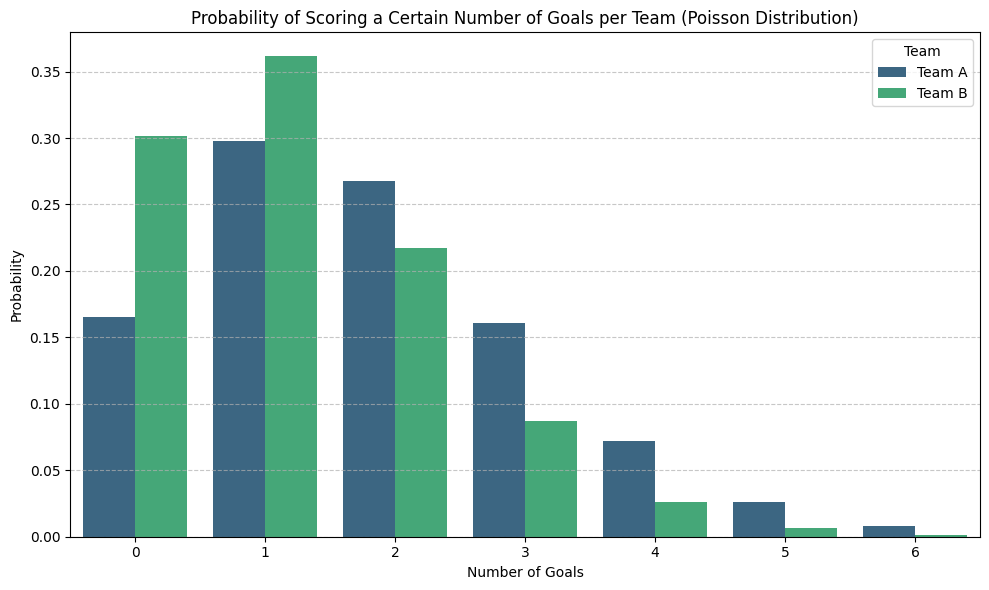

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set max_goals to 6 for this plot
max_goals = 6
goals = list(range(max_goals + 1))

# Recalculate goal probabilities for Team A and Team B
team_A_goal_probs = [poisson.pmf(i, team_A_xG) for i in range(max_goals + 1)]
team_B_goal_probs = [poisson.pmf(i, team_B_xG) for i in range(max_goals + 1)]

team_A_df = pd.DataFrame({
    'Goals': goals,
    'Probability': team_A_goal_probs,
    'Team': 'Team A'
})
team_B_df = pd.DataFrame({
    'Goals': goals,
    'Probability': team_B_goal_probs,
    'Team': 'Team B'
})

goal_probs_df = pd.concat([team_A_df, team_B_df])

plt.figure(figsize=(10, 6))
sns.barplot(x='Goals', y='Probability', hue='Team', data=goal_probs_df, palette='viridis')
plt.title('Probability of Scoring a Certain Number of Goals per Team (Poisson Distribution)')
plt.xlabel('Number of Goals')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Team')
plt.tight_layout()
plt.show()

## Heatmap of Final Scorelines

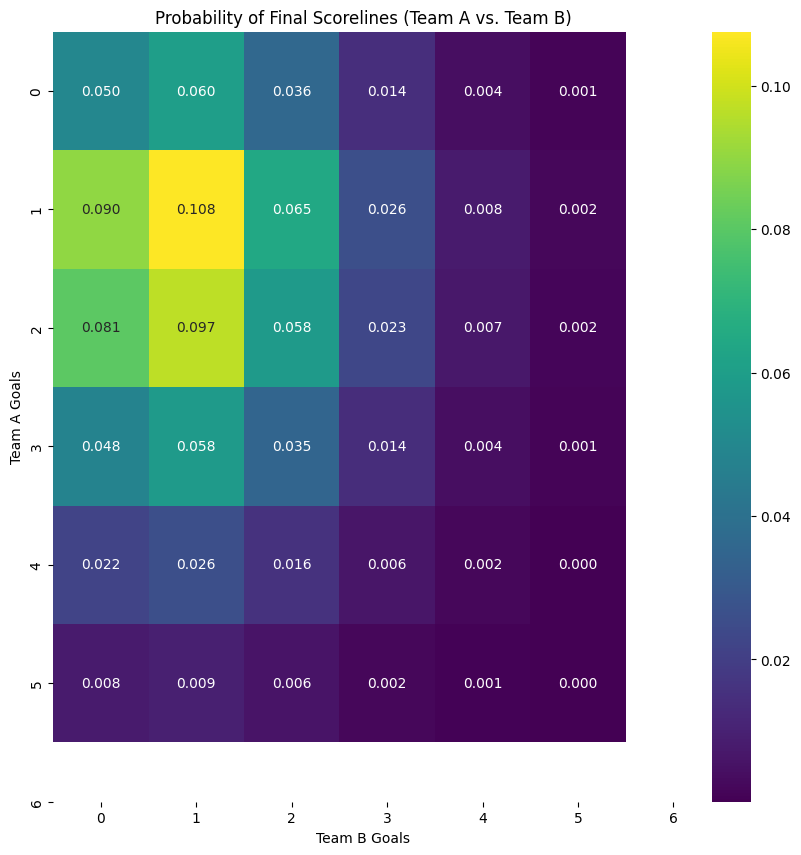

In [26]:
goal_labels = [str(i) for i in range(max_goals + 1)]

plt.figure(figsize=(10, 10))
sns.heatmap(
    match_probs,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=goal_labels,
    yticklabels=goal_labels
)

plt.title('Probability of Final Scorelines (Team A vs. Team B)')
plt.xlabel('Team B Goals')
plt.ylabel('Team A Goals')
plt.show()

## Visualize Cumulative Performance

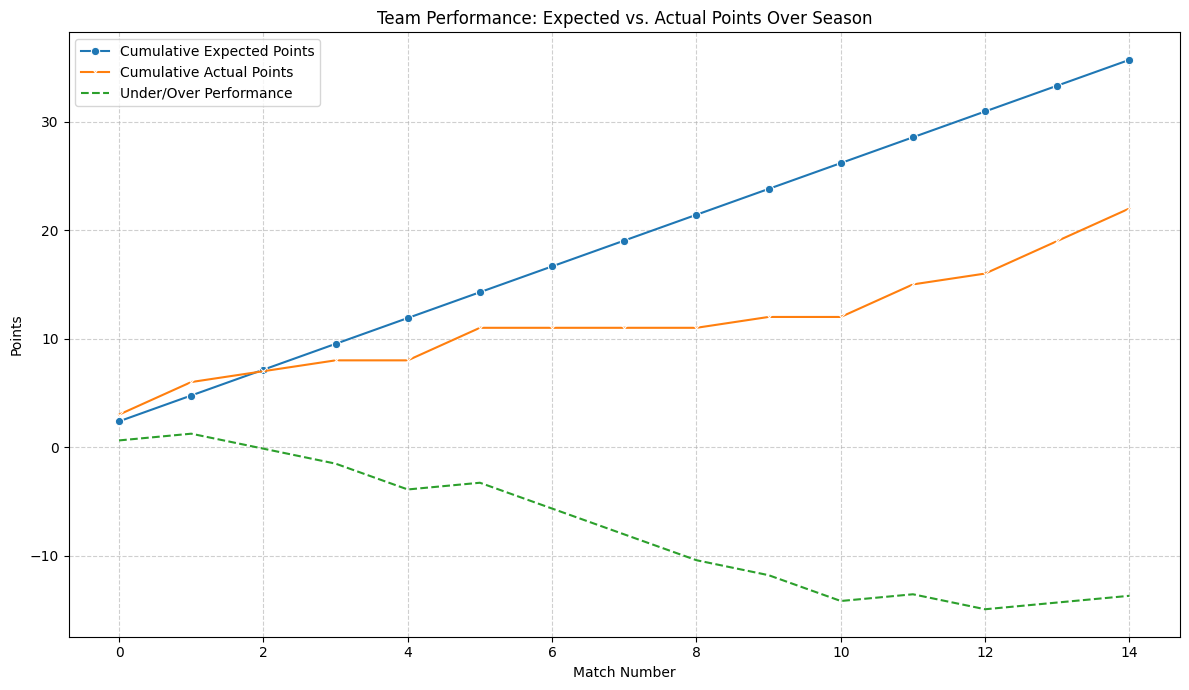

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for a single team, e.g., 'Orlando Pride'
team_name = 'Orlando Pride'
season_df = data[data['home_team'] == team_name].copy()
season_df = season_df.reset_index(drop=True)

# Rename columns for clarity
season_df['goals_for'] = season_df['home_score']
season_df['goals_against'] = season_df['away_score']

# Assign expected points for each match (using the same value for demonstration)
# In practice, you should calculate this per match
season_df['expected_points'] = expected_points

# Calculate actual points for each match
def calculate_actual_points(row):
    if row['goals_for'] > row['goals_against']:
        return 3 # Win
    elif row['goals_for'] == row['goals_against']:
        return 1 # Draw
    else:
        return 0 # Loss

season_df['actual_points'] = season_df.apply(calculate_actual_points, axis=1)

# Calculate cumulative expected points
season_df['cumulative_expected_points'] = season_df['expected_points'].cumsum()

# Calculate cumulative actual points
season_df['cumulative_actual_points'] = season_df['actual_points'].cumsum()

# Calculate 'Under/Over' performance
season_df['under_over_performance'] = season_df['cumulative_actual_points'] - season_df['cumulative_expected_points']

plt.figure(figsize=(12, 7))
sns.lineplot(x=season_df.index, y='cumulative_expected_points', data=season_df, label='Cumulative Expected Points', marker='o')
sns.lineplot(x=season_df.index, y='cumulative_actual_points', data=season_df, label='Cumulative Actual Points', marker='x')
sns.lineplot(x=season_df.index, y='under_over_performance', data=season_df, label='Under/Over Performance', linestyle='--')

plt.title('Team Performance: Expected vs. Actual Points Over Season')
plt.xlabel('Match Number')
plt.ylabel('Points')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()